# Chapter 10: Exploratory Data Analysis

*Data Analytics with Python and Jupyter Notebook*

We explore four weeks of individual Bean There transactions (March 2026)
using a repeatable five-step process:

1. Shape and types
2. Data quality
3. One variable at a time
4. Relationships
5. Write down what you find

Run each cell in order with **Shift + Enter**.

## Setup

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.width", 80)
pd.set_option("display.max_columns", 12)

## Step 1: Shape and types

In [2]:
tx = pd.read_csv(
    "../data/ch10_bean_there_transactions.csv",
    parse_dates=["timestamp"],
)
tx.shape

(4000, 11)

In [3]:
tx.head(3).T

,0,1,2
transaction_id,T00001,T00002,T00003
timestamp,2026-03-02 06:13:00,2026-03-02 06:19:00,2026-03-02 06:23:00
store,Downtown,Downtown,University
channel,In store,In store,Mobile app
payment,Card,Card,App
loyalty_member,Yes,No,Yes
items,2,2,1
total,7.5,7.75,2.95
tip,0.82,0.81,0.0
wait_min,7.0,7.0,1.4


In [4]:
tx.info()

<class 'pandas.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 11 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   transaction_id  4000 non-null   str           
 1   timestamp       4000 non-null   datetime64[us]
 2   store           4000 non-null   str           
 3   channel         4000 non-null   str           
 4   payment         4000 non-null   str           
 5   loyalty_member  4000 non-null   str           
 6   items           4000 non-null   int64         
 7   total           4000 non-null   float64       
 8   tip             4000 non-null   float64       
 9   wait_min        4000 non-null   float64       
 10  rating          1392 non-null   float64       
dtypes: datetime64[us](1), float64(4), int64(1), str(5)
memory usage: 343.9 KB


In [5]:
tx.nunique()

transaction_id    4000
timestamp         3530
store                3
channel              2
payment              4
loyalty_member       2
items               18
total              127
tip                265
wait_min           221
rating               5
dtype: int64

## Step 2: Data quality

In [6]:
tx.isna().sum()

transaction_id       0
timestamp            0
store                0
channel              0
payment              0
loyalty_member       0
items                0
total                0
tip                  0
wait_min             0
rating            2608
dtype: int64

In [7]:
print("Duplicate rows:", tx.duplicated().sum())
print("IDs unique:", tx["transaction_id"].is_unique)
print("From", tx["timestamp"].min(), "to", tx["timestamp"].max())

Duplicate rows: 0
IDs unique: True
From 2026-03-02 06:13:00 to 2026-03-29 16:54:00


In [8]:
tx.describe(include="number").round(2)

,items,total,tip,wait_min,rating
count,4000.00,4000.00,4000.00,4000.00,1392.00
mean,1.77,6.86,0.54,4.40,3.96
std,1.66,6.60,0.85,4.18,1.07
min,1.00,0.00,0.00,0.30,1.00
25%,1.00,4.25,0.00,1.70,3.00
50%,1.00,4.75,0.00,3.20,4.00
75%,2.00,8.75,0.86,5.60,5.00
max,35.00,148.90,20.51,38.00,5.00


In [9]:
tx.describe(include="str")

,transaction_id,store,channel,payment,loyalty_member
count,4000,4000,4000,4000,4000
unique,4000,3,2,4,2
top,T00001,Downtown,In store,Card,No
freq,1,1791,3026,2394,2227


In [10]:
tx.loc[tx["total"] == 0, "payment"].value_counts()

payment
Voucher    41
Name: count, dtype: int64

In [11]:
cols = ["timestamp", "store", "items", "total", "wait_min"]
tx.nlargest(5, "total")[cols]

,timestamp,store,items,total,wait_min
2286,2026-03-18 08:24:00,Downtown,35,148.90,19.8
2492,2026-03-19 11:45:00,Downtown,34,132.80,20.1
3183,2026-03-24 09:50:00,Downtown,33,128.85,18.7
627,2026-03-06 09:47:00,Downtown,30,111.35,19.5
2291,2026-03-18 08:34:00,Downtown,29,111.35,19.1


## Step 3: One variable at a time

In [12]:
nums = ["total", "items", "wait_min", "tip"]
tx[nums].agg(["mean", "median", "skew"]).round(2)

,total,items,wait_min,tip
mean,6.86,1.77,4.40,0.54
median,4.75,1.00,3.20,0.00
skew,11.88,12.15,2.55,7.39


In [13]:
tx["total"].quantile([0.10, 0.25, 0.50, 0.75, 0.90, 0.99])

0.10     3.00
0.25     4.25
0.50     4.75
0.75     8.75
0.90    11.95
0.99    18.25
Name: total, dtype: float64

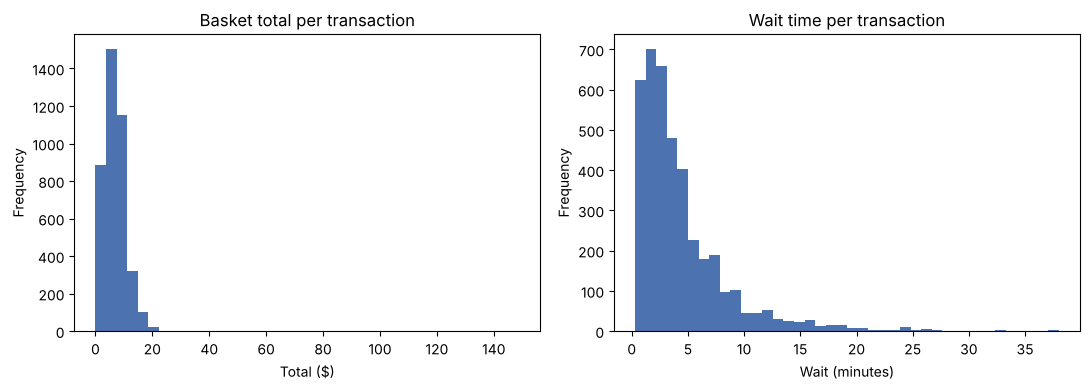

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

tx["total"].plot(kind="hist", bins=40, ax=axes[0], color="#4C72B0")
axes[0].set_title("Basket total per transaction")
axes[0].set_xlabel("Total ($)")

tx["wait_min"].plot(kind="hist", bins=40, ax=axes[1], color="#4C72B0")
axes[1].set_title("Wait time per transaction")
axes[1].set_xlabel("Wait (minutes)")

plt.tight_layout()
fig.savefig("../figures/ch10-distributions.png", dpi=150)
plt.show()

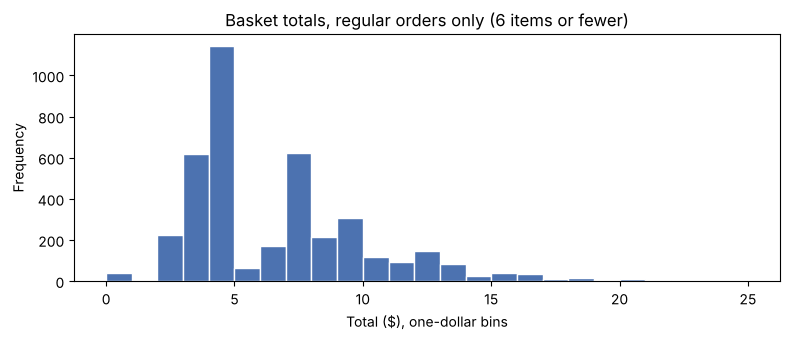

In [15]:
regular = tx[tx["items"] <= 6]
fig, ax = plt.subplots(figsize=(8, 3.5))
regular["total"].plot(kind="hist", bins=range(0, 26), ax=ax,
                      color="#4C72B0", edgecolor="white")
ax.set_title("Basket totals, regular orders only (6 items or fewer)")
ax.set_xlabel("Total ($), one-dollar bins")
plt.tight_layout()
fig.savefig("../figures/ch10-totals-zoom.png", dpi=150)
plt.show()

In [16]:
regular["total"].value_counts().head(8)

total
4.50    499
4.25    339
3.25    338
4.75    304
3.00    280
2.95    226
7.50    179
7.75    157
Name: count, dtype: int64

In [17]:
for col in ["store", "channel", "payment", "loyalty_member"]:
    shares = tx[col].value_counts(normalize=True).round(3)
    print(shares.to_dict())

{'Downtown': 0.448, 'Riverside': 0.282, 'University': 0.27}
{'In store': 0.756, 'Mobile app': 0.244}
{'Card': 0.598, 'App': 0.238, 'Cash': 0.153, 'Voucher': 0.01}
{'No': 0.557, 'Yes': 0.443}


In [18]:
tx["hour"] = tx["timestamp"].dt.hour
tx["weekend"] = tx["timestamp"].dt.dayofweek >= 5
tx["hour"].value_counts().sort_index()

hour
6      93
7     255
8     504
9     583
10    444
11    445
12    434
13    359
14    317
15    247
16    196
17    123
Name: count, dtype: int64

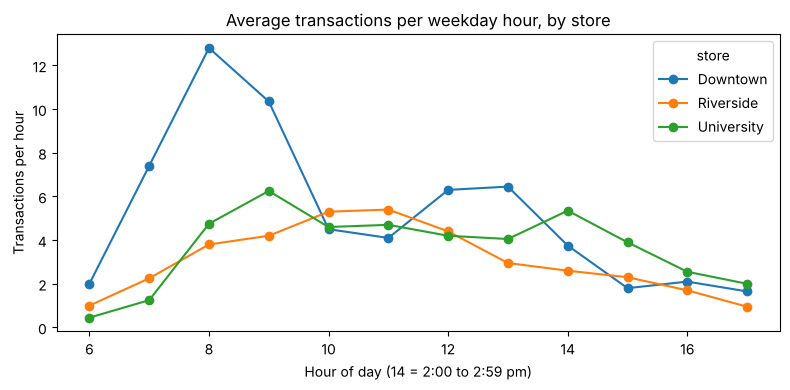

In [19]:
hourly = (
    tx[~tx["weekend"]]
    .groupby(["hour", "store"])
    .size()
    .unstack()
    / 20
)

fig, ax = plt.subplots(figsize=(8, 4))
hourly.plot(ax=ax, marker="o")
ax.set_title("Average transactions per weekday hour, by store")
ax.set_xlabel("Hour of day (14 = 2:00 to 2:59 pm)")
ax.set_ylabel("Transactions per hour")
plt.tight_layout()
fig.savefig("../figures/ch10-hourly.png", dpi=150)
plt.show()

In [20]:
tx["rating"].value_counts(dropna=False).sort_index()

rating
1.0      49
2.0      95
3.0     254
4.0     460
5.0     534
NaN    2608
Name: count, dtype: int64

In [21]:
tx["rating"].notna().groupby(tx["loyalty_member"]).mean().round(3)

loyalty_member
No     0.254
Yes    0.466
Name: rating, dtype: float64

## Step 4: Relationships

In [22]:
nums = ["items", "total", "tip", "wait_min", "rating"]
tx[nums].corr().round(2)

,items,total,tip,wait_min,rating
items,1.00,0.99,0.50,0.17,-0.13
total,0.99,1.00,0.52,0.17,-0.13
tip,0.50,0.52,1.00,-0.02,0.06
wait_min,0.17,0.17,-0.02,1.00,-0.66
rating,-0.13,-0.13,0.06,-0.66,1.00


In [23]:
small = tx[tx["items"] <= 6]
small[nums].corr().round(2)

,items,total,tip,wait_min,rating
items,1.00,0.96,0.43,-0.03,0.01
total,0.96,1.00,0.44,-0.02,-0.00
tip,0.43,0.44,1.00,-0.11,0.08
wait_min,-0.03,-0.02,-0.11,1.00,-0.65
rating,0.01,-0.00,0.08,-0.65,1.00


In [24]:
bands = pd.cut(
    tx["wait_min"],
    bins=[0, 2, 4, 6, 8, 10, 40],
    labels=["0-2", "2-4", "4-6", "6-8", "8-10", "10+"],
)
by_wait = tx.groupby(bands, observed=True)["rating"].agg(["mean", "count"])
by_wait.round(2)

,mean,count
wait_min,,
0-2,4.44,487
2-4,4.24,404
4-6,3.86,221
6-8,3.43,117
8-10,3.15,55
10+,1.94,108


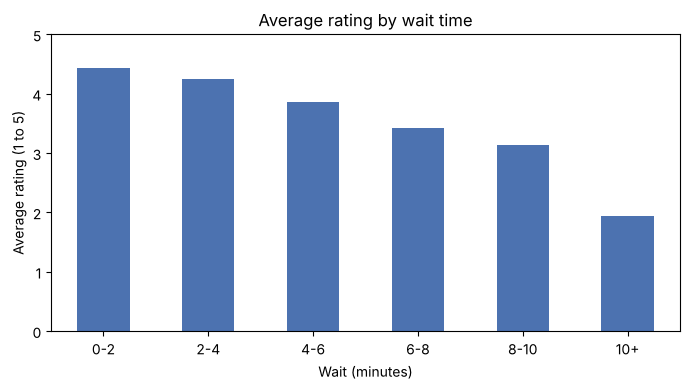

In [25]:
fig, ax = plt.subplots(figsize=(7, 4))
by_wait["mean"].plot(kind="bar", ax=ax, color="#4C72B0")
ax.set_title("Average rating by wait time")
ax.set_xlabel("Wait (minutes)")
ax.set_ylabel("Average rating (1 to 5)")
ax.set_ylim(0, 5)
ax.tick_params(axis="x", rotation=0)
plt.tight_layout()
fig.savefig("../figures/ch10-wait-rating.png", dpi=150)
plt.show()

In [26]:
(
    tx.groupby("store")
    .agg(
        transactions=("transaction_id", "count"),
        avg_total=("total", "mean"),
        median_wait=("wait_min", "median"),
        avg_rating=("rating", "mean"),
    )
    .round(2)
)

,transactions,avg_total,median_wait,avg_rating
store,,,,
Downtown,1791,7.26,3.9,3.73
Riverside,1128,6.58,3.0,4.22
University,1081,6.48,2.6,4.06


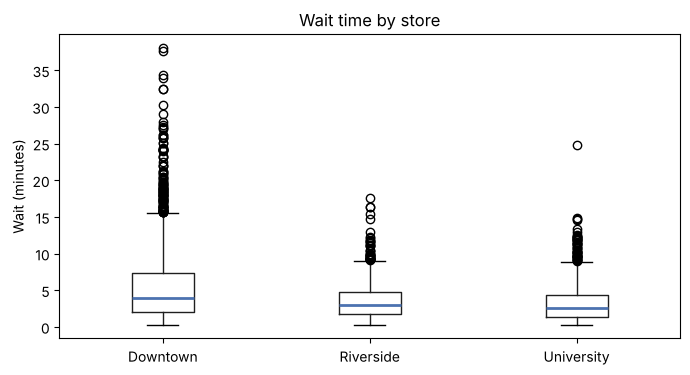

In [27]:
fig, ax = plt.subplots(figsize=(7, 4))
tx.boxplot(column="wait_min", by="store", ax=ax, grid=False,
           medianprops={"color": "#4C72B0", "linewidth": 2})
ax.set_title("Wait time by store")
ax.set_xlabel("")
ax.set_ylabel("Wait (minutes)")
fig.suptitle("")
plt.tight_layout()
fig.savefig("../figures/ch10-wait-by-store.png", dpi=150)
plt.show()

In [28]:
tx.groupby("loyalty_member")[["items", "total"]].mean().round(2)

,items,total
loyalty_member,,
No,1.58,6.14
Yes,2.02,7.76


In [29]:
pd.crosstab(tx["store"], tx["channel"], normalize="index").round(2)

channel,In store,Mobile app
store,,
Downtown,0.78,0.22
Riverside,0.89,0.11
University,0.58,0.42


In [30]:
pd.crosstab(tx["store"], tx["payment"], normalize="index").round(2)

payment,App,Card,Cash,Voucher
store,,,,
Downtown,0.22,0.65,0.12,0.01
Riverside,0.10,0.62,0.26,0.01
University,0.41,0.48,0.10,0.01


## Digging into surprises

In [31]:
(
    tx[~tx["weekend"]]
    .pivot_table(index="hour", columns="store",
                 values="wait_min", aggfunc="median")
    .round(1)
)

store,Downtown,Riverside,University
hour,,,
6,3.4,2.1,1.7
7,5.0,2.3,2.1
8,9.9,2.5,2.6
9,7.1,3.3,3.4
10,2.8,3.6,2.6
11,3.6,3.4,3.0
12,4.8,3.0,3.2
13,3.5,2.5,2.8
14,2.8,2.2,2.9


In [32]:
tx.groupby("channel")["wait_min"].median()

channel
In store      4.0
Mobile app    1.5
Name: wait_min, dtype: float64

In [33]:
(
    tx.groupby("payment")
    .agg(
        avg_tip=("tip", "mean"),
        share_with_tip=("tip", lambda s: (s > 0).mean()),
    )
    .round(2)
)

,avg_tip,share_with_tip
payment,,
App,0.83,0.70
Card,0.57,0.55
Cash,0.00,0.00
Voucher,0.00,0.00


In [34]:
paid = tx[tx["payment"].isin(["Card", "App"]) & (tx["total"] > 0)]
tip_pct = paid["tip"] / paid["total"] * 100
tip_pct[paid["tip"] > 0].groupby(paid["payment"]).median().round(1)

payment
App     16.8
Card    14.9
dtype: float64

## Step 5: Write down what you find

Keep a findings log in a Markdown cell like this one. Each finding gets the
evidence that supports it and how confident you are.

**Findings log: Bean There transactions, March 2026**

1. **Most customers buy one thing.** Median basket $4.75; the six most common totals are the six menu prices. *High confidence.*
2. **A few catering orders distort averages.** 14 orders of 12+ items (up to $148.90), all Downtown weekday mornings. Report medians, or analyze them separately. *High confidence.*
3. **Downtown's 8 am rush is slow.** Weekday median wait 9.9 minutes at 8 am vs about 3 minutes the rest of the day. *High confidence.*
4. **Long waits cost ratings.** Average rating falls from 4.4 (under 2 minutes) to 1.9 (over 10 minutes); correlation -0.66, unchanged without catering orders. *High confidence that they move together; we can't yet say waits cause the low ratings.*
5. **App orders are faster.** Median 1.5 vs 4.0 minutes. University uses the app most (42%), Riverside least (11%). *High confidence.*
6. **Loyalty members spend more.** 2.0 vs 1.6 items, $7.76 vs $6.14. *Cause unknown.*
7. **Survey answers are biased toward members.** Response rate 47% vs 25%. Treat the average rating with care. *Medium confidence it matters.*
8. **Cash tips are not recorded.** All 611 cash transactions show $0.00 tip. *Question for the owner: is this how the till works?*
9. **$0.00 totals are loyalty vouchers** (41 rows), not errors.

## Exercises

1. Compare weekdays with weekends: how many transactions does each store have, and what is the average basket total? *Hint:* group by `["store", "weekend"]` and use named aggregations.
2. Compare the median wait for mobile app and in-store orders inside each store. Where does the app save customers the most time? *Hint:* group by two columns, then `.unstack()`.
3. For Card and App payments that include a tip, compute the tip as a percentage of the total. Which payment type tips more generously, by mean and by median?
4. Does the link between waiting and ratings hold inside each store? *Hint:* loop over `tx.groupby("store")` and use `grp["wait_min"].corr(grp["rating"])`.
5. **Survey bias.** What is the average rating of loyalty members versus non-members? Can you explain the difference using what you found about channels and wait times?
6. Find the single busiest hour (date and hour) at Downtown. How many transactions happened in it, and what was the median wait? *Hint:* `tx["timestamp"].dt.floor("h")` rounds each time down to the hour.
7. **Think about it:** write a three-point findings log for Riverside alone, with the evidence for each point.

Solutions are in Appendix D of the book.